# Plain Autoencoder Pretraining of Swin Transformer Encoder

**Standard autoencoder** pretraining for 2D confocal microscopy patches.  
**Strategy:** Encode full image with Swin Transformer → compress to flat latent vector `z` → CNN decoder reconstructs full input → **weighted MSE loss** (bright pixels upweighted 10×).

Key differences from the MAE approach:
1. **Information bottleneck** via a flat latent vector `z` forces compression
2. **Weighted MSE loss** — upweights bright (puncta) pixels by 10× to prevent the model from ignoring sparse signal
3. **ConvTranspose2d decoder** — reconstructs from `z` through progressive upsampling

After pretraining, only the Swin Transformer encoder weights are kept and transferred to SwinUNETR for segmentation fine-tuning.

## A. Setup & Imports

In [18]:
import os, sys, time, math

# Prevent OpenBLAS from spawning too many threads (causes hangs on HPC)
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

from types import SimpleNamespace
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset
from tqdm.auto import tqdm

# Add project root to path (notebook lives in models/)
sys.path.insert(0, os.path.abspath("../.."))

from data_utils.patch_dataset import PatchDataset

In [19]:
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU available")

NVIDIA A40
Memory: 47.7 GB


## B. Configuration

In [20]:
args = SimpleNamespace(
    # Data
    data_root="../../data/patches_128",
    val_split=0.2,
    seed=42,

    # Model
    in_channels=3,
    img_size=128,
    feature_size=48,           # Swin embed_dim
    spatial_dims=2,
    dropout_path_rate=0.0,
    use_checkpoint=False,

    # Autoencoder
    bright_weight=10.0,        # upweight bright pixels in MSE loss

    # Training
    epochs=200,
    batch_size=32,
    lr=1.5e-4,
    weight_decay=0.05,
    warmup_epochs=10,

    # Output
    save_dir="./checkpoints",
    encoder_save_name="pretrained_encoder_ae.pt",

    experiment_name="pretrain_ae_swin",
    experiment_counter=0
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
os.makedirs(args.save_dir, exist_ok=True)

# Derived geometry
args.patch_size    = 2                                            # Swin patch_size
args.token_grid    = args.img_size // args.patch_size             # 128//2 = 64
args.window_size   = args.token_grid // 8                         # 64//8  = 8
args.enc_channels  = args.feature_size * (2 ** 4)                 # 48*16  = 768
args.enc_spatial   = args.img_size // 32                          # 128//32 = 4
args.n_dec_upsample = int(math.log2(args.img_size // args.enc_spatial))  # log2(32) = 5

print(f"Swin token grid:      {args.token_grid}x{args.token_grid}")
print(f"Window size:          {args.window_size}x{args.window_size}")
print(f"Encoder output:       {args.enc_channels} ch, {args.enc_spatial}x{args.enc_spatial} spatial")
print(f"Decoder upsample:     {args.n_dec_upsample} stages ({args.enc_spatial}x{args.enc_spatial} -> {args.img_size}x{args.img_size})")

Device: cuda
Swin token grid:      64x64
Window size:          8x8
Encoder output:       768 ch, 4x4 spatial
Decoder upsample:     5 stages (4x4 -> 128x128)


## C. Autoencoder Model (Encoder + CNN Decoder)

- **Encoder:** MONAI SwinTransformer → spatial feature map at deepest stage
- **Decoder:** ConvTranspose2d stack from spatial features up to full resolution

In [21]:
from monai.networks.nets.swin_unetr import SwinTransformer

class AESwinPretrainer(nn.Module):
    """
    Plain autoencoder with Swin Transformer encoder.

    Encoder (KEPT):  MONAI SwinTransformer → deepest-stage spatial feature map
    Decoder (DISCARDED): ConvTranspose2d stack → Sigmoid
    
    The spatial feature map at stage 4 serves as the bottleneck.
    No pooling or FC layers are used, following MONAI's ViTAutoEnc design.
    """
    def __init__(self, args):
        super().__init__()

        patch_size  = (args.patch_size,) * args.spatial_dims
        window_size = (args.window_size,) * args.spatial_dims

        # --- ENCODER (kept after pretraining) ---
        self.swinViT = SwinTransformer(
            in_chans         = args.in_channels,
            embed_dim        = args.feature_size,
            window_size      = window_size,
            patch_size        = patch_size,
            depths           = [2, 2, 2, 2],
            num_heads        = [3, 6, 12, 24],
            mlp_ratio        = 4.0,
            qkv_bias         = True,
            drop_rate        = 0.0,
            attn_drop_rate   = 0.0,
            drop_path_rate   = args.dropout_path_rate,
            norm_layer       = torch.nn.LayerNorm,
            use_checkpoint   = args.use_checkpoint,
            spatial_dims     = args.spatial_dims,
        )

        # --- DECODER (discarded after pretraining) ---
        # Stage 4 output: (B, feature_size * 2^4, img_size / 32, img_size / 32)
        enc_ch = args.feature_size * (2 ** 4)  # 768 for feature_size=48
        spatial = args.img_size // 32           # 4 for img_size=128

        # ConvTranspose2d stack: spatial -> img_size (5 doublings: 4->8->16->32->64->128)
        n_ups = int(math.log2(args.img_size // spatial))
        blocks = []
        in_ch = enc_ch
        for i in range(n_ups):
            is_last = (i == n_ups - 1)
            out_ch = args.in_channels if is_last else max(in_ch // 2, 32)
            blocks.append(
                nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1, bias=False)
            )
            if is_last:
                blocks.append(nn.Sigmoid())
            else:
                blocks.append(nn.BatchNorm2d(out_ch))
                blocks.append(nn.LeakyReLU(0.01, inplace=True))
            in_ch = out_ch
        self.decoder = nn.Sequential(*blocks)

    def encode(self, x):
        """Return deepest-stage spatial feature map."""
        return self.swinViT(x.contiguous())[4]  # (B, enc_ch, S, S)

    def decode(self, z):
        """Upsample spatial features to image resolution."""
        return self.decoder(z)                  # (B, C, img_size, img_size)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)

print("AESwinPretrainer defined.")

AESwinPretrainer defined.


## D. Instantiate Model

In [22]:
model = AESwinPretrainer(args).to(device)

total_params   = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in model.swinViT.parameters())
decoder_params = sum(p.numel() for p in model.decoder.parameters())

print(f"Total parameters:              {total_params:,}")
print(f"Encoder parameters (kept):     {encoder_params:,}")
print(f"Decoder parameters (disc):     {decoder_params:,}")

# Verify forward pass shapes
with torch.no_grad():
    dummy = torch.zeros(2, args.in_channels, args.img_size, args.img_size).to(device)
    out = model(dummy)
assert out.shape == dummy.shape, f"Shape mismatch: {out.shape} != {dummy.shape}"
print(f"Forward pass OK: {dummy.shape} -> {out.shape}")
print(f"Output range (zeros input): [{out.min():.4f}, {out.max():.4f}]")

# Verify encoder output is spatial, not flat
with torch.no_grad():
    z = model.encode(dummy)
print(f"Encoder output shape: {z.shape}  (expected: [2, {args.enc_channels}, {args.enc_spatial}, {args.enc_spatial}])")

Total parameters:              12,582,858
Encoder parameters (kept):     6,312,234
Decoder parameters (disc):     6,270,624
Forward pass OK: torch.Size([2, 3, 128, 128]) -> torch.Size([2, 3, 128, 128])
Output range (zeros input): [0.0132, 0.9744]
Encoder output shape: torch.Size([2, 768, 4, 4])  (expected: [2, 768, 4, 4])


## E. Dataset & DataLoaders

In [23]:
# Load dataset (exclude KONTROLA control samples)
dataset = PatchDataset(root=args.data_root, exclude_patterns=["KONTROLA"])
print(f"Total patches (before corruption filter): {len(dataset)}")

Total patches (before corruption filter): 21708


In [25]:
# Sanity check
sample = dataset[0]
print(f"Sample shape: {sample.shape}, dtype: {sample.dtype}")
print(f"Value range: [{sample.min():.4f}, {sample.max():.4f}]")
assert sample.ndim == 3, f"Expected 3D tensor (C,H,W), got {sample.ndim}D"
assert 0 <= sample.min() and sample.max() <= 1.0 + 1e-6, "Values should be in [0,1]"
print("\u2713 Data sanity checks passed")

# Train/val split
generator = torch.Generator().manual_seed(args.seed)
n_val = int(len(dataset) * args.val_split)
n_train = len(dataset) - n_val
train_dataset, val_dataset = random_split(dataset, [n_train, n_val], generator=generator)
print(f"Train: {n_train}, Validation: {n_val}")

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=args.batch_size, shuffle=False,
                        num_workers=0, pin_memory=True)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Sample shape: torch.Size([3, 128, 128]), dtype: torch.float32
Value range: [0.0000, 0.8915]
✓ Data sanity checks passed
Train: 17367, Validation: 4341
Train batches: 543, Val batches: 136


## F. Training Setup

- **Loss:** Weighted MSE — bright pixels (puncta) get 10× weight to prevent the network from learning to output uniform dark backgrounds
- **Optimizer:** AdamW with cosine schedule + linear warmup

In [26]:
def weighted_mse_loss(pred, target, bright_weight=10.0):
    """MSE loss that upweights bright pixels.

    Weight per pixel scales linearly from 1.0 (dark) to bright_weight (max intensity).
    This prevents the model from collapsing to predicting near-zero everywhere,
    which would achieve low unweighted MSE on sparse fluorescence images.

    Args:
        pred:   (B, C, H, W) model output
        target: (B, C, H, W) original image, values in [0, 1]
        bright_weight: weight multiplier for pixels at intensity 1.0
    Returns:
        scalar loss
    """
    weights = 1.0 + (bright_weight - 1.0) * target  # 0->1, 1->bright_weight
    diff_sq = (pred - target) ** 2
    return (weights * diff_sq).mean()


optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)

# Cosine schedule with linear warmup
def lr_lambda(epoch):
    if epoch < args.warmup_epochs:
        return epoch / max(1, args.warmup_epochs)
    progress = (epoch - args.warmup_epochs) / max(1, args.epochs - args.warmup_epochs)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print("Training setup ready.")
print(f"  Loss: weighted MSE (bright_weight={args.bright_weight})")
print(f"  Optimizer: AdamW (lr={args.lr}, wd={args.weight_decay})")
print(f"  Schedule: cosine with {args.warmup_epochs}-epoch warmup")

Training setup ready.
  Loss: weighted MSE (bright_weight=10.0)
  Optimizer: AdamW (lr=0.00015, wd=0.05)
  Schedule: cosine with 10-epoch warmup


## G. Overfit Sanity Check

Verify the model can memorize 16 samples.  
If the autoencoder can't overfit a tiny batch, something is wrong with the architecture or loss.

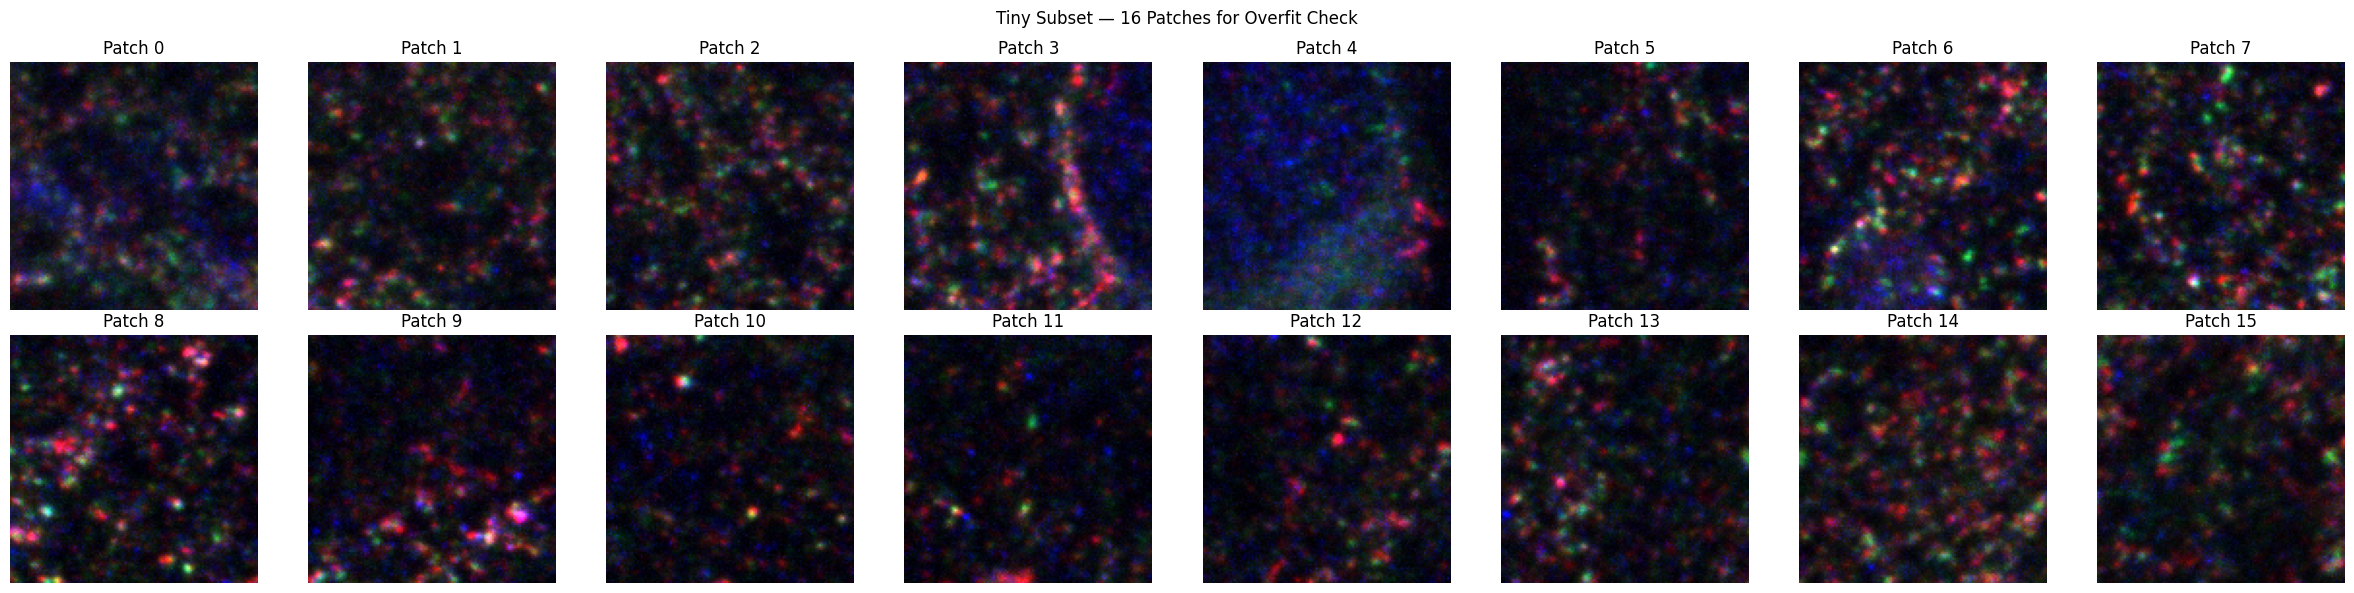

In [27]:
# --- Overfit on 16 patches ---
tiny = Subset(dataset, range(16))
tiny_loader = DataLoader(tiny, batch_size=16, shuffle=False)

# Visualize the 16 patches
fig, axes = plt.subplots(2, 8, figsize=(24, 6))
for i, ax in enumerate(axes.flat):
    patch = tiny[i]
    if patch.shape[0] >= 3:
        ax.imshow(patch[:3].permute(1, 2, 0).numpy())
    else:
        ax.imshow(patch[0].numpy(), cmap="gray")
    ax.set_title(f"Patch {i}")
    ax.axis("off")
plt.suptitle("Tiny Subset \u2014 16 Patches for Overfit Check")
plt.tight_layout()
plt.show()

In [28]:
# Debug: check actual feature shapes from encoder
model.eval()
with torch.no_grad():
    dummy = torch.randn(1, args.in_channels, args.img_size, args.img_size).to(device)
    features = model.swinViT(dummy)
    for i, f in enumerate(features):
        print(f"s{i}: {f.shape}")
    z = model.encode(dummy)
    print(f"latent z: {z.shape}")

s0: torch.Size([1, 48, 64, 64])
s1: torch.Size([1, 96, 32, 32])
s2: torch.Size([1, 192, 16, 16])
s3: torch.Size([1, 384, 8, 8])
s4: torch.Size([1, 768, 4, 4])
latent z: torch.Size([1, 768, 4, 4])


In [31]:
# Overfit sanity check: verify the model can memorize 4 patches
model.train()
opt_test = torch.optim.Adam(model.parameters(), lr=5e-4)
# x_fixed = next(iter(tiny_loader))[:4].to(device)
x_fixed = torch.stack([dataset[0], dataset[100], dataset[200], dataset[300]]).to(device)

scaler_test = torch.amp.GradScaler(device.type, enabled=device.type == "cuda")

# Stop when loss improvement over last 50 steps is negligible
max_steps = 2000
check_every = 25
plateau_window = 100  # compare current loss to loss 100 steps ago
plateau_threshold = 1e-4  # minimum relative improvement to continue
loss_history = []

for step in tqdm(range(max_steps), desc="Overfit"):
    opt_test.zero_grad(set_to_none=True)
    with torch.amp.autocast(device.type, enabled=device.type == "cuda"):
        recon = model(x_fixed)
        loss = weighted_mse_loss(recon, x_fixed, args.bright_weight)
    scaler_test.scale(loss).backward()
    scaler_test.step(opt_test)
    scaler_test.update()

    current_loss = loss.item()
    loss_history.append(current_loss)

    if step % check_every == 0:
        tqdm.write(f"Step {step:4d} | Weighted MSE: {current_loss:.6f}")

    # # Check plateau after enough history
    # if len(loss_history) > plateau_window:
    #     old_loss = loss_history[-plateau_window]
    #     relative_improvement = (old_loss - current_loss) / (old_loss + 1e-8)
    #     if relative_improvement < plateau_threshold:
    #         tqdm.write(f"Plateau at step {step} | Loss: {current_loss:.6f} "
    #                    f"(improved {relative_improvement:.2e} over last {plateau_window} steps)")
    #         break

print(f"Final loss: {loss_history[-1]:.6f} after {len(loss_history)} steps")

Overfit:   0%|          | 0/2000 [00:00<?, ?it/s]

Step    0 | Weighted MSE: 0.069675
Step   25 | Weighted MSE: 0.056299
Step   50 | Weighted MSE: 0.041250
Step   75 | Weighted MSE: 0.022028
Step  100 | Weighted MSE: 0.011804
Step  125 | Weighted MSE: 0.006672
Step  150 | Weighted MSE: 0.004993
Step  175 | Weighted MSE: 0.003743
Step  200 | Weighted MSE: 0.003022
Step  225 | Weighted MSE: 0.002701
Step  250 | Weighted MSE: 0.002197
Step  275 | Weighted MSE: 0.002070
Step  300 | Weighted MSE: 0.001835
Step  325 | Weighted MSE: 0.001462
Step  350 | Weighted MSE: 0.001451
Step  375 | Weighted MSE: 0.001194
Step  400 | Weighted MSE: 0.001174
Step  425 | Weighted MSE: 0.001029
Step  450 | Weighted MSE: 0.000944
Step  475 | Weighted MSE: 0.001183
Step  500 | Weighted MSE: 0.000802
Step  525 | Weighted MSE: 0.000976
Step  550 | Weighted MSE: 0.000703
Step  575 | Weighted MSE: 0.000751
Step  600 | Weighted MSE: 0.000610
Step  625 | Weighted MSE: 0.000671
Step  650 | Weighted MSE: 0.000563
Step  675 | Weighted MSE: 0.000607
Step  700 | Weighted

In [32]:
# # Overfit training (small batch + autocast for speed at 512x512)
# model.train()
# opt_test = torch.optim.Adam(model.parameters(), lr=5e-4)

# x_fixed = next(iter(tiny_loader))[:4].to(device)  # 4 samples is enough for overfit check

# scaler_test = torch.amp.GradScaler(device.type, enabled=device.type == "cuda")

# for step in tqdm(range(500), desc="Overfit"):
#     opt_test.zero_grad(set_to_none=True)
#     with torch.amp.autocast(device.type, enabled=device.type == "cuda"):
#         recon = model(x_fixed)
#         loss = weighted_mse_loss(recon, x_fixed, args.bright_weight)
#     scaler_test.scale(loss).backward()
#     scaler_test.step(opt_test)
#     scaler_test.update()
#     if step % 25 == 0:
#         tqdm.write(f"Step {step:4d} | Weighted MSE: {loss.item():.6f}")

In [34]:
import json
from datetime import datetime

# Save overfit checkpoint + experiment log
overfit_ckpt_path = os.path.join(args.save_dir, "overfit_sanity_check.pt")
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": opt_test.state_dict(),
    "overfit_steps": len(loss_history),
    "final_loss": loss_history[-1],
}, overfit_ckpt_path)
print(f"Saved overfit checkpoint: {overfit_ckpt_path}")

# Compute reconstructions for per-sample MSE
model.eval()
with torch.no_grad():
    recons = model(x_fixed)

run_tag = "early_stop"
# Write experiment log
log = {
    "timestamp": datetime.now().isoformat(),
    "run_tag": run_tag,
    "experiment_counter": args.experiment_counter,
    "experiment": "overfit_sanity_check",
    "model": "AESwinPretrainer",
    "config": {k: v for k, v in vars(args).items() if isinstance(v, (int, float, str, bool))},
    "overfit": {
        "n_samples": len(x_fixed),
        "steps": len(loss_history),
        "optimizer": "Adam",
        "lr": 5e-4,
        "final_weighted_mse": loss_history[-1],
        "per_sample_mse": [
            ((recons[i] - x_fixed[i]) ** 2).mean().item()
            for i in range(len(x_fixed))
        ],
    },
    "device": str(device),
}

log_path = os.path.join(args.save_dir, f"overfit_{run_tag}_log.json")
with open(log_path, "w") as f:
    json.dump(log, f, indent=2)
print(f"Saved experiment log: {log_path}")
print(f"Run: {run_tag} (counter={args.experiment_counter})")

Saved overfit checkpoint: ./checkpoints/overfit_sanity_check.pt
Saved experiment log: ./checkpoints/overfit_early_stop_log.json
Run: early_stop (counter=0)


In [35]:
model.eval()
with torch.no_grad():
    recons = model(x_fixed)
    
    per_sample_mse = ((recons - x_fixed) ** 2).mean(dim=(1,2,3))
    for i, mse in enumerate(per_sample_mse):
        print(f"Patch {i}: MSE = {mse.item():.6f}")

Patch 0: MSE = 0.000127
Patch 1: MSE = 0.000118
Patch 2: MSE = 0.000097
Patch 3: MSE = 0.000099


In [36]:
# --- Diagnostic: verify reconstructions are distinct (not mode-collapsed) ---
# Reconstruction similarities should roughly mirror original similarities.
# If all recon similarities are ~1.0, the model is ignoring its input.
with torch.no_grad():
    recons = model(x_fixed)
    
    # Pairwise similarity between reconstructions
    n = recons.shape[0]
    recons_flat = recons.reshape(n, -1)
    
    # Also flatten originals for comparison
    orig_flat = x_fixed.reshape(n, -1)
    
    print("=== Pairwise cosine similarity between RECONSTRUCTIONS ===")
    for i in range(n):
        for j in range(i+1, n):
            sim = F.cosine_similarity(recons_flat[i:i+1], recons_flat[j:j+1]).item()
            print(f"  recon[{i}] vs recon[{j}]: {sim:.4f}")
    
    print("\n=== Pairwise cosine similarity between ORIGINALS ===")
    for i in range(n):
        for j in range(i+1, n):
            sim = F.cosine_similarity(orig_flat[i:i+1], orig_flat[j:j+1]).item()
            print(f"  orig[{i}] vs orig[{j}]: {sim:.4f}")

=== Pairwise cosine similarity between RECONSTRUCTIONS ===
  recon[0] vs recon[1]: 0.6076
  recon[0] vs recon[2]: 0.6378
  recon[0] vs recon[3]: 0.7084
  recon[1] vs recon[2]: 0.5215
  recon[1] vs recon[3]: 0.5339
  recon[2] vs recon[3]: 0.6287

=== Pairwise cosine similarity between ORIGINALS ===
  orig[0] vs orig[1]: 0.5965
  orig[0] vs orig[2]: 0.6287
  orig[0] vs orig[3]: 0.6987
  orig[1] vs orig[2]: 0.5126
  orig[1] vs orig[3]: 0.5245
  orig[2] vs orig[3]: 0.6215


In [38]:
# Persist overfit sanity-check results: save model checkpoint and write a JSON
# experiment log with per-sample MSE, hyperparameters, and convergence metadata.
# This lets us compare overfit runs across experiments without re-running them.
with torch.no_grad():
    zs = model.encode(x_fixed)
    for i in range(len(zs)):
        print(f"z[{i}] norm: {zs[i].norm():.4f}, mean: {zs[i].mean():.6f}")
    
    zs_flat = zs.flatten(1)  # (B, C*H*W)
    for i in range(len(zs_flat)):
        for j in range(i+1, len(zs_flat)):
            sim = F.cosine_similarity(zs_flat[i:i+1], zs_flat[j:j+1]).item()
            print(f"z[{i}] vs z[{j}]: {sim:.6f}")

z[0] norm: 110.8512, mean: -0.000000
z[1] norm: 110.8512, mean: -0.000000
z[2] norm: 110.8512, mean: -0.000000
z[3] norm: 110.8512, mean: 0.000000
z[0] vs z[1]: 0.485501
z[0] vs z[2]: 0.330934
z[0] vs z[3]: 0.582860
z[1] vs z[2]: 0.055978
z[1] vs z[3]: 0.148290
z[2] vs z[3]: 0.107699


In [40]:
with torch.no_grad():
    # Grab an unseen patch
    unseen = dataset[100].unsqueeze(0).to(device)
    
    recon_seen   = model(x_fixed[0:1])       # trained-on patch
    recon_unseen = model(unseen)              # never-seen patch
    
    # If model collapsed, recon_unseen will look like recon_seen
    diff = (recon_seen - recon_unseen).abs().mean().item()
    print(f"Mean abs diff between seen vs unseen reconstruction: {diff:.6f}")

Mean abs diff between seen vs unseen reconstruction: 0.107748


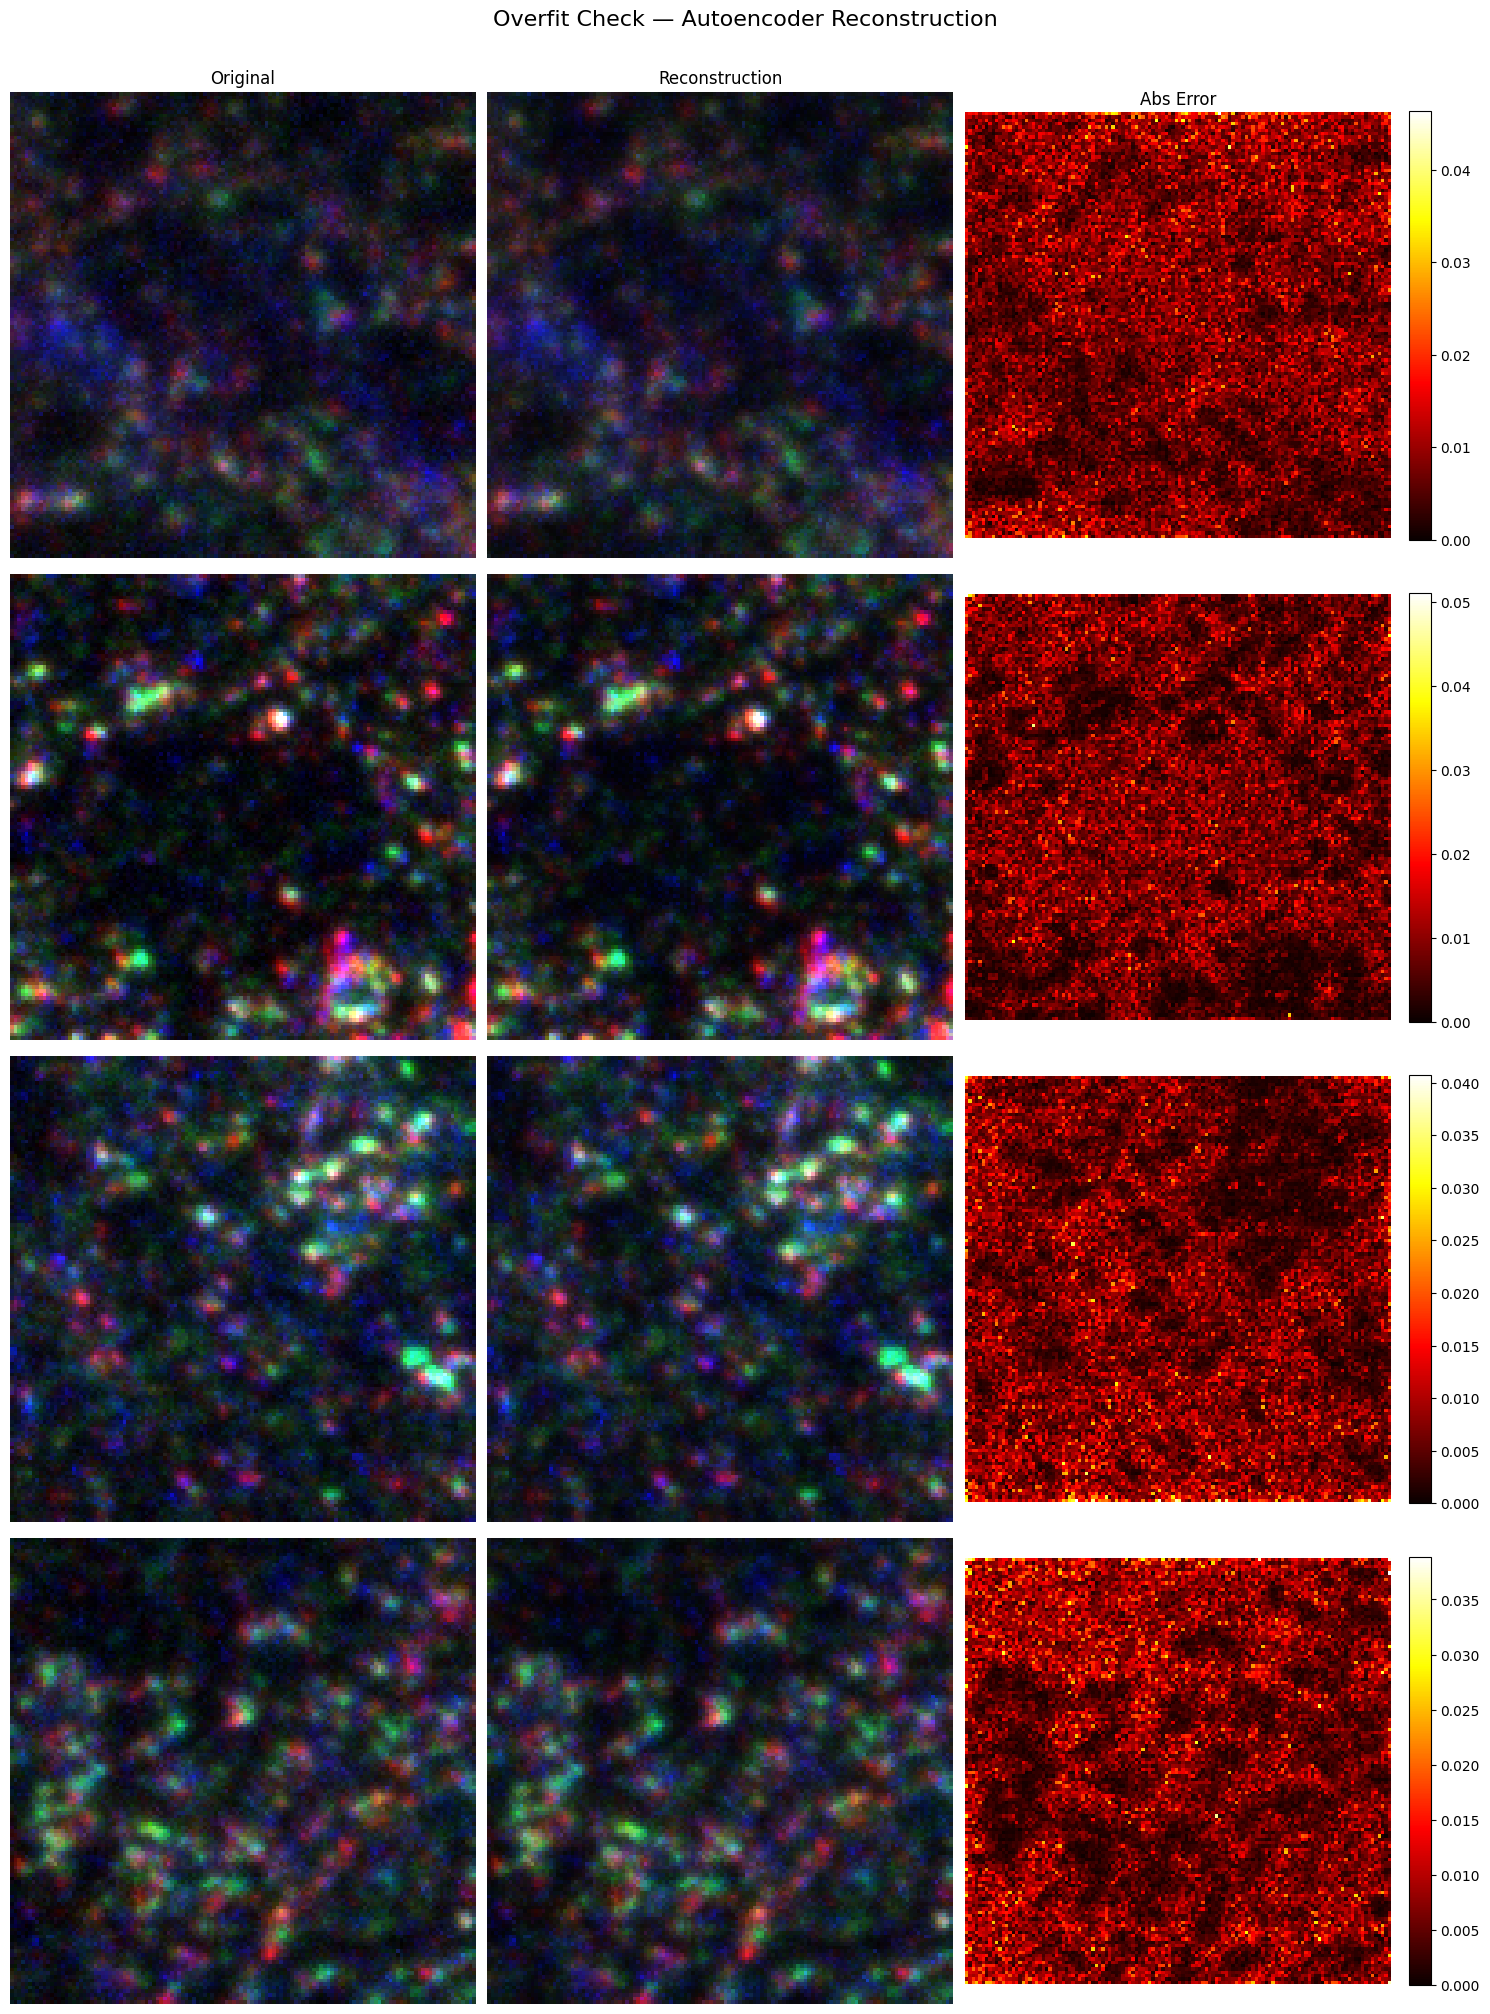

In [42]:
# --- Reconstruction visualization on the 16 overfit patches ---
model.eval()

with torch.no_grad():
    recon = model(x_fixed)

n_show = min(8, len(x_fixed))
fig, axes = plt.subplots(n_show, 3, figsize=(15, n_show * 5))
col_titles = ["Original", "Reconstruction", "Abs Error"]

for i in range(n_show):
    orig = x_fixed[i].cpu()
    rec = recon[i].cpu()

    orig_rgb = orig[:3].permute(1, 2, 0).clamp(0, 1).numpy()
    recon_rgb = rec[:3].permute(1, 2, 0).clamp(0, 1).numpy()
    diff = (orig[:3] - rec[:3]).abs().mean(dim=0).numpy()

    axes[i, 0].imshow(orig_rgb)
    axes[i, 1].imshow(recon_rgb)
    im = axes[i, 2].imshow(diff, cmap="magma", vmin=0, vmax=max(diff.max(), 0.01))
    plt.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04)

    for j, title in enumerate(col_titles):
        if i == 0:
            axes[i, j].set_title(title, fontsize=12)
        axes[i, j].axis("off")

plt.suptitle("Overfit Check \u2014 Autoencoder Reconstruction", fontsize=16, y=1.005)
plt.tight_layout()
plt.show()

In [44]:
# --- Diagnostic: check if SwinViT spatial features are distinct BEFORE pooling ---
# This isolates whether the Swin encoder or the pool+FC bottleneck kills the signal.
with torch.no_grad():
    feats = model.swinViT(x_fixed.contiguous())
    stage4 = feats[4]  # (B, C, H, W) — deepest stage
    print(f"Stage 4 shape: {stage4.shape}")
    
    flat = stage4.flatten(1)  # (B, C*H*W)
    for i in range(len(flat)):
        for j in range(i+1, len(flat)):
            sim = F.cosine_similarity(flat[i:i+1], flat[j:j+1]).item()
            print(f"stage4[{i}] vs stage4[{j}]: {sim:.6f}")

Stage 4 shape: torch.Size([4, 768, 4, 4])
stage4[0] vs stage4[1]: 0.485501
stage4[0] vs stage4[2]: 0.330934
stage4[0] vs stage4[3]: 0.582860
stage4[1] vs stage4[2]: 0.055978
stage4[1] vs stage4[3]: 0.148290
stage4[2] vs stage4[3]: 0.107699


In [45]:
# --- Diagnostic: check all Swin stages to find where inputs become indistinguishable ---
with torch.no_grad():
    feats = model.swinViT(x_fixed.contiguous())
    for s, feat in enumerate(feats):
        print(f"\nStage {s}: {feat.shape}")
        flat = feat.flatten(1)
        for i in range(len(flat)):
            for j in range(i+1, len(flat)):
                sim = F.cosine_similarity(flat[i:i+1], flat[j:j+1]).item()
                print(f"  [{i}] vs [{j}]: {sim:.6f}")


Stage 0: torch.Size([4, 48, 64, 64])
  [0] vs [1]: 0.934232
  [0] vs [2]: 0.932311
  [0] vs [3]: 0.945820
  [1] vs [2]: 0.909781
  [1] vs [3]: 0.915201
  [2] vs [3]: 0.926321

Stage 1: torch.Size([4, 96, 32, 32])
  [0] vs [1]: 0.583807
  [0] vs [2]: 0.438895
  [0] vs [3]: 0.564915
  [1] vs [2]: 0.201480
  [1] vs [3]: 0.280522
  [2] vs [3]: 0.287066

Stage 2: torch.Size([4, 192, 16, 16])
  [0] vs [1]: 0.524466
  [0] vs [2]: 0.369497
  [0] vs [3]: 0.501280
  [1] vs [2]: 0.119202
  [1] vs [3]: 0.195685
  [2] vs [3]: 0.206266

Stage 3: torch.Size([4, 384, 8, 8])
  [0] vs [1]: 0.445360
  [0] vs [2]: 0.361362
  [0] vs [3]: 0.514009
  [1] vs [2]: 0.053571
  [1] vs [3]: 0.089391
  [2] vs [3]: 0.140813

Stage 4: torch.Size([4, 768, 4, 4])
  [0] vs [1]: 0.485501
  [0] vs [2]: 0.330934
  [0] vs [3]: 0.582860
  [1] vs [2]: 0.055978
  [1] vs [3]: 0.148290
  [2] vs [3]: 0.107699


In [46]:
# --- Diagnostic: did Swin weights move at all during overfit? ---
# Compare current weights to a fresh init
fresh = AESwinPretrainer(args)
torch.manual_seed(args.seed)  # won't match exactly, but let's check magnitude
with torch.no_grad():
    for (name, p_trained), (_, p_fresh) in zip(
        model.swinViT.named_parameters(),
        fresh.swinViT.named_parameters()
    ):
        diff = (p_trained.cpu() - p_fresh).abs().mean().item()
        print(f"{name}: mean abs diff = {diff:.8f}")
        break  # just check first layer to get the idea

patch_embed.proj.weight: mean abs diff = 0.19476990


## H. Re-initialize Model for Full Training

After verifying the overfit works, re-initialize the model with fresh weights for proper training.

In [47]:
# Fresh model
model = AESwinPretrainer(args).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
print("Model re-initialized for full training.")

Model re-initialized for full training.


## I. Training loop

### TRAINING LOGGING CELLS

In [53]:
# =====================================================================
# Experiment metadata + CSV logger setup
# =====================================================================

import csv
import json
from datetime import datetime

# Experiment metadata — everything needed to reproduce this run
experiment_meta = {
    "experiment_name":   args.experiment_name,
    "start_time":        datetime.now().isoformat(),
    "device":            str(device),
    "gpu_name":          torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    "gpu_memory_gb":     round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1) if torch.cuda.is_available() else 0,
    "pytorch_version":   torch.__version__,
    "cuda_version":      torch.version.cuda if torch.cuda.is_available() else "N/A",

    # Data
    "n_train":           len(train_loader.dataset),
    "n_val":             len(val_loader.dataset),
    "n_train_batches":   len(train_loader),
    "n_val_batches":     len(val_loader),
    "patch_size_px":     args.img_size,
    "in_channels":       args.in_channels,

    # Architecture
    "encoder":           "SwinTransformer (MONAI, spatial_dims=2)",
    "feature_size":      args.feature_size,
    "enc_channels":      args.enc_channels,
    "enc_spatial":       args.enc_spatial,
    "window_size":       args.window_size,
    "decoder":           f"ConvTranspose2d x{args.n_dec_upsample} stages",
    "total_params":      sum(p.numel() for p in model.parameters()),
    "encoder_params":    sum(p.numel() for p in model.swinViT.parameters()),
    "decoder_params":    sum(p.numel() for p in model.decoder.parameters()),

    # Training
    "optimizer":         "AdamW",
    "lr":                args.lr,
    "weight_decay":      args.weight_decay,
    "batch_size":        args.batch_size,
    "epochs":            args.epochs,
    "warmup_epochs":     args.warmup_epochs,
    "scheduler":         "linear warmup + cosine decay",
    "bright_weight":     args.bright_weight,
    "loss_fn":           "weighted_mse (bright_weight={})".format(args.bright_weight),
    "mixed_precision":   device.type == "cuda",
    "grad_clip_norm":    1.0,
    "seed":              args.seed,
}

In [54]:
# Print summary
print("=" * 60)
print(f"Experiment: {experiment_meta['experiment_name']}")
print(f"Device:     {experiment_meta['gpu_name']}")
print(f"Train:      {experiment_meta['n_train']} patches, {experiment_meta['n_train_batches']} batches")
print(f"Val:        {experiment_meta['n_val']} patches, {experiment_meta['n_val_batches']} batches")
print(f"Params:     {experiment_meta['total_params']:,} total "
      f"({experiment_meta['encoder_params']:,} enc + {experiment_meta['decoder_params']:,} dec)")
print("=" * 60)

Experiment: pretrain_ae_swin
Device:     NVIDIA A40
Train:      17367 patches, 543 batches
Val:        4341 patches, 136 batches
Params:     12,582,858 total (6,312,234 enc + 6,270,624 dec)


In [55]:
# CSV log file — one row per epoch, easy to load later for plots
csv_path = os.path.join(args.save_dir, f"{args.experiment_name}_log.csv")
csv_fields = [
    "epoch", "train_loss", "val_loss", "lr",
    "epoch_time_s", "train_time_s", "val_time_s",
    "best_val_loss", "best_epoch",
    "grad_norm_mean", "grad_norm_max"
]
csv_file = open(csv_path, "w", newline="")
csv_writer = csv.DictWriter(csv_file, fieldnames=csv_fields)
csv_writer.writeheader()

print(f"Logging to: {csv_path}")

Logging to: ./checkpoints/pretrain_ae_swin_log.csv


### Training

In [56]:
# =====================================================================
# Training loop with full logging
# =====================================================================

best_val_loss  = float("inf")
best_epoch     = 0
train_losses   = []
val_losses     = []
lr_history     = []
grad_norms     = []   # track gradient health
epoch_times    = []
total_train_start = time.time()

scaler = torch.amp.GradScaler(device.type, enabled=device.type == "cuda")

for epoch in range(1, args.epochs + 1):
    # --- Training ---
    model.train()
    running_loss = 0.0
    epoch_grad_norms = []
    train_start = time.time()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{args.epochs} [train]", leave=False)
    for batch_idx, x in enumerate(pbar, 1):
        x = x.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device.type, enabled=device.type == "cuda"):
            recon = model(x)
            loss  = weighted_mse_loss(recon, x, args.bright_weight)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        # Log gradient norm before clipping
        total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        epoch_grad_norms.append(total_norm.item())

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix(loss=f"{running_loss / batch_idx:.6f}")

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    train_time = time.time() - train_start
    scheduler.step()

    # --- Validation ---
    model.eval()
    val_running_loss = 0.0
    val_start = time.time()

    with torch.no_grad():
        for x in tqdm(val_loader, desc=f"Epoch {epoch}/{args.epochs} [val]", leave=False):
            x = x.to(device, non_blocking=True)
            with torch.amp.autocast(device.type, enabled=device.type == "cuda"):
                recon = model(x)
                loss  = weighted_mse_loss(recon, x, args.bright_weight)
            val_running_loss += loss.item()

    val_loss = val_running_loss / len(val_loader)
    val_losses.append(val_loss)
    val_time = time.time() - val_start

    # --- Bookkeeping ---
    current_lr = scheduler.get_last_lr()[0]
    lr_history.append(current_lr)
    epoch_time = train_time + val_time
    epoch_times.append(epoch_time)
    mean_grad = sum(epoch_grad_norms) / len(epoch_grad_norms)
    max_grad  = max(epoch_grad_norms)
    grad_norms.append(mean_grad)

    improved = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        improved = " *best*"
        torch.save({
            "epoch":               epoch,
            "model_state_dict":    model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss":            val_loss,
            "train_loss":          train_loss,
            "args":                vars(args),
        }, os.path.join(args.save_dir, "best_ae_model.pt"))

    # Periodic checkpoint every 25 epochs
    if epoch % 25 == 0:
        torch.save({
            "epoch":            epoch,
            "model_state_dict": model.state_dict(),
            "val_loss":         val_loss,
            "train_loss":       train_loss,
        }, os.path.join(args.save_dir, f"ae_epoch_{epoch}.pt"))

    # Print epoch summary
    print(f"Epoch {epoch:3d}/{args.epochs} | "
          f"Train: {train_loss:.6f} | Val: {val_loss:.6f} | "
          f"LR: {current_lr:.2e} | Grad: {mean_grad:.2f} | "
          f"{epoch_time:.1f}s{improved}")

    # Write CSV row
    csv_writer.writerow({
        "epoch":          epoch,
        "train_loss":     f"{train_loss:.8f}",
        "val_loss":       f"{val_loss:.8f}",
        "lr":             f"{current_lr:.2e}",
        "epoch_time_s":   f"{epoch_time:.1f}",
        "train_time_s":   f"{train_time:.1f}",
        "val_time_s":     f"{val_time:.1f}",
        "best_val_loss":  f"{best_val_loss:.8f}",
        "best_epoch":     best_epoch,
        "grad_norm_mean": f"{mean_grad:.4f}",
        "grad_norm_max":  f"{max_grad:.4f}",
    })
    csv_file.flush()  # flush every epoch so data survives crashes

total_train_time = time.time() - total_train_start
print(f"\nTraining complete in {total_train_time/3600:.2f} hours.")
print(f"Best val loss: {best_val_loss:.6f} at epoch {best_epoch}")
csv_file.close()

Epoch 1/200 [train]:   0%|          | 0/543 [00:00<?, ?it/s]

Epoch 1/200 [val]:   0%|          | 0/136 [00:00<?, ?it/s]

Epoch   1/200 | Train: 0.347753 | Val: 0.347790 | LR: 1.50e-05 | Grad: 0.57 | 1273.9s *best*


Epoch 2/200 [train]:   0%|          | 0/543 [00:00<?, ?it/s]

Epoch 2/200 [val]:   0%|          | 0/136 [00:00<?, ?it/s]

...

Epoch 199/200 [val]:   0%|          | 0/136 [00:00<?, ?it/s]

Epoch 199/200 | Train: 0.003854 | Val: 0.003894 | LR: 1.03e-08 | Grad: 0.01 | 57.5s *best*


Epoch 200/200 [train]:   0%|          | 0/543 [00:00<?, ?it/s]

Epoch 200/200 [val]:   0%|          | 0/136 [00:00<?, ?it/s]

Epoch 200/200 | Train: 0.003854 | Val: 0.003896 | LR: 0.00e+00 | Grad: 0.01 | 58.4s

Training complete in 3.84 hours.
Best val loss: 0.003894 at epoch 199


### Save experiment summary JSON

In [57]:
experiment_meta["end_time"]         = datetime.now().isoformat()
experiment_meta["total_time_hours"] = round(total_train_time / 3600, 2)
experiment_meta["total_time_s"]     = round(total_train_time, 1)
experiment_meta["avg_epoch_time_s"] = round(sum(epoch_times) / len(epoch_times), 1)
experiment_meta["best_val_loss"]    = best_val_loss
experiment_meta["best_epoch"]       = best_epoch
experiment_meta["final_train_loss"] = train_losses[-1]
experiment_meta["final_val_loss"]   = val_losses[-1]

json_path = os.path.join(args.save_dir, f"{args.experiment_name}_meta.json")
with open(json_path, "w") as f:
    json.dump(experiment_meta, f, indent=2, default=str)
print(f"Saved experiment metadata: {json_path}")

Saved experiment metadata: ./checkpoints/pretrain_ae_swin_meta.json


###  Plateau detection + summary

In [58]:
import numpy as np

def detect_plateau(losses, window=10, threshold=0.001):
    """Find the epoch where val loss stops improving meaningfully.

    Computes relative improvement over a sliding window.
    Plateau = first epoch where improvement drops below threshold
    for `window` consecutive epochs.
    """
    if len(losses) < window + 1:
        return len(losses), "too few epochs"

    for i in range(window, len(losses)):
        recent = losses[i - window : i]
        best_before = min(losses[:i - window]) if i > window else losses[0]
        best_recent = min(recent)
        rel_improvement = (best_before - best_recent) / (best_before + 1e-12)

        if rel_improvement < threshold:
            return i - window + 1, f"{rel_improvement:.6f}"  # epoch is 1-indexed later

    return len(losses), "no plateau detected"

In [59]:
plateau_epoch, plateau_info = detect_plateau(val_losses, window=10, threshold=0.001)

print("=" * 60)
print("TRAINING SUMMARY (for thesis)")
print("=" * 60)
print(f"Total epochs:         {len(train_losses)}")
print(f"Total training time:  {total_train_time/3600:.2f} hours ({total_train_time:.0f}s)")
print(f"Avg epoch time:       {sum(epoch_times)/len(epoch_times):.1f}s")
print(f"")
print(f"Best val loss:        {best_val_loss:.6f} at epoch {best_epoch}")
print(f"Final train loss:     {train_losses[-1]:.6f}")
print(f"Final val loss:       {val_losses[-1]:.6f}")
print(f"Train/val gap:        {val_losses[-1] - train_losses[-1]:.6f}")
print(f"")
print(f"Plateau detected:     epoch ~{plateau_epoch} (rel_improv: {plateau_info})")
print(f"Loss at plateau:      train={train_losses[plateau_epoch-1]:.6f}, "
      f"val={val_losses[plateau_epoch-1]:.6f}")
print(f"")
print(f"Initial train loss:   {train_losses[0]:.6f}")
print(f"Initial val loss:     {val_losses[0]:.6f}")
print(f"Total reduction:      {(1 - val_losses[-1]/val_losses[0])*100:.1f}%")
print("=" * 60)

TRAINING SUMMARY (for thesis)
Total epochs:         200
Total training time:  3.84 hours (13809s)
Avg epoch time:       67.7s

Best val loss:        0.003894 at epoch 199
Final train loss:     0.003854
Final val loss:       0.003896
Train/val gap:        0.000043

Plateau detected:     epoch ~189 (rel_improv: 0.000555)
Loss at plateau:      train=0.003861, val=0.003897

Initial train loss:   0.347753
Initial val loss:     0.347790
Total reduction:      98.9%


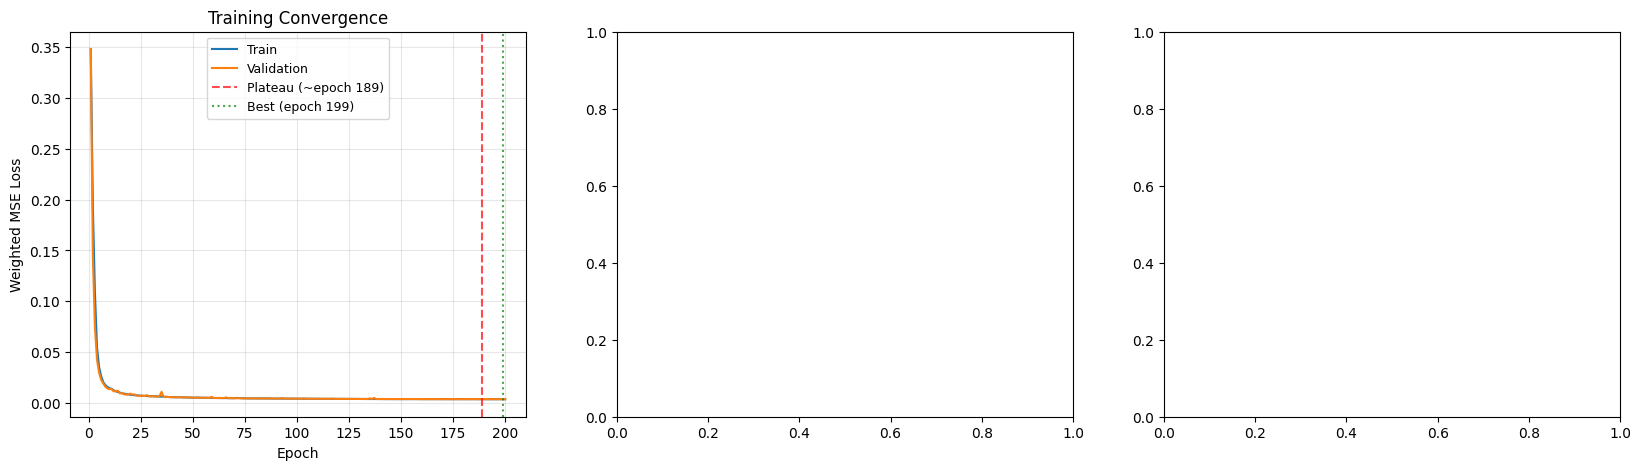

In [60]:
# =====================================================================
# Loss curve plots
# =====================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
epochs_range = np.arange(1, len(train_losses) + 1)

# --- Panel 1: Linear scale with plateau marker ---
ax = axes[0]
ax.plot(epochs_range, train_losses, label="Train", linewidth=1.5)
ax.plot(epochs_range, val_losses, label="Validation", linewidth=1.5)
ax.axvline(x=plateau_epoch, color="red", linestyle="--", alpha=0.7, label=f"Plateau (~epoch {plateau_epoch})")
ax.axvline(x=best_epoch, color="green", linestyle=":", alpha=0.7, label=f"Best (epoch {best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Weighted MSE Loss")
ax.set_title("Training Convergence")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

In [61]:
# --- Panel 2: Log scale (shows early rapid descent) ---
ax = axes[1]
ax.semilogy(epochs_range, train_losses, label="Train", linewidth=1.5)
ax.semilogy(epochs_range, val_losses, label="Validation", linewidth=1.5)
ax.axvline(x=plateau_epoch, color="red", linestyle="--", alpha=0.7)
ax.set_xlabel("Epoch")
ax.set_ylabel("Weighted MSE Loss (log)")
ax.set_title("Loss (log scale)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

<Figure size 640x480 with 0 Axes>

Saved: ./checkpoints/pretrain_ae_swin_curves.png


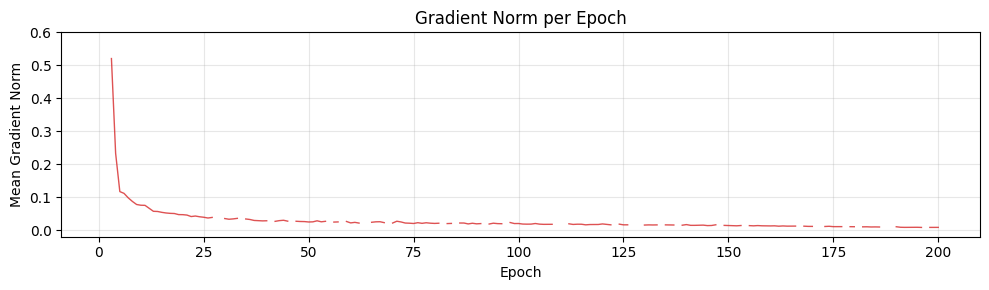

Saved: ./checkpoints/pretrain_ae_swin_gradnorms.png


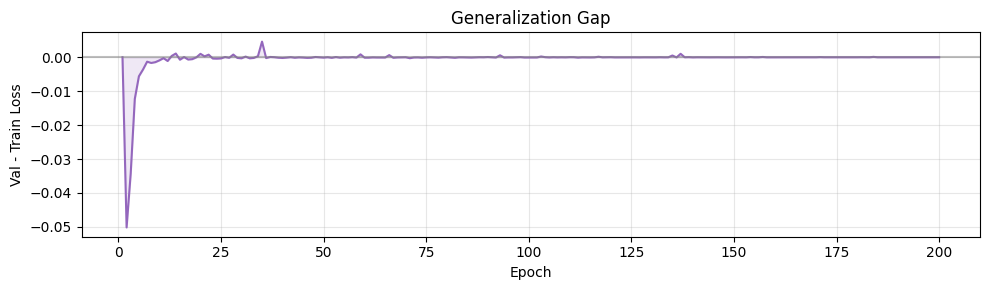

Saved: ./checkpoints/pretrain_ae_swin_gap.png


In [62]:
# --- Panel 3: Learning rate schedule ---
ax = axes[2]
ax.plot(epochs_range, lr_history, color="tab:orange", linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("LR Schedule")
ax.grid(True, alpha=0.3)
ax.ticklabel_format(style="scientific", axis="y", scilimits=(0,0))

plt.tight_layout()
fig_path = os.path.join(args.save_dir, f"{args.experiment_name}_curves.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


# --- Gradient norm plot (detects training instability) ---
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(epochs_range, grad_norms, color="tab:red", linewidth=1, alpha=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Gradient Norm")
ax.set_title("Gradient Norm per Epoch")
ax.grid(True, alpha=0.3)
plt.tight_layout()
grad_fig_path = os.path.join(args.save_dir, f"{args.experiment_name}_gradnorms.png")
plt.savefig(grad_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {grad_fig_path}")


# --- Train/val gap plot (detects overfitting) ---
fig, ax = plt.subplots(figsize=(10, 3))
gap = np.array(val_losses) - np.array(train_losses)
ax.plot(epochs_range, gap, color="tab:purple", linewidth=1.5)
ax.axhline(y=0, color="gray", linestyle="-", alpha=0.5)
ax.fill_between(epochs_range, 0, gap, alpha=0.15, color="tab:purple")
ax.set_xlabel("Epoch")
ax.set_ylabel("Val - Train Loss")
ax.set_title("Generalization Gap")
ax.grid(True, alpha=0.3)
plt.tight_layout()
gap_fig_path = os.path.join(args.save_dir, f"{args.experiment_name}_gap.png")
plt.savefig(gap_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {gap_fig_path}")

## Inspect CSV log (useful after resuming)

In [63]:
import pandas as pd

df = pd.read_csv(csv_path)
print(f"Log has {len(df)} epochs")
print(f"\nFirst 5 epochs:")
print(df.head().to_string(index=False))
print(f"\nLast 5 epochs:")
print(df.tail().to_string(index=False))
print(f"\nBest epoch by val_loss:")
best_row = df.loc[df["val_loss"].idxmin()]
print(best_row.to_string())

Log has 200 epochs

First 5 epochs:
 epoch  train_loss  val_loss       lr  epoch_time_s  train_time_s  val_time_s  best_val_loss  best_epoch  grad_norm_mean  grad_norm_max
     1    0.347753  0.347790 0.000015        1273.9        1021.8       252.2       0.347790           1          0.5720         0.5936
     2    0.194734  0.144566 0.000030          58.7          52.3         6.4       0.144566           2             inf            inf
     3    0.108856  0.074570 0.000045          59.7          51.5         8.1       0.074570           3          0.5207        24.1019
     4    0.055020  0.042786 0.000060          59.8          53.1         6.7       0.042786           4          0.2335         7.4928
     5    0.035534  0.029956 0.000075          62.7          55.4         7.3       0.029956           5          0.1176         0.7598

Last 5 epochs:
 epoch  train_loss  val_loss           lr  epoch_time_s  train_time_s  val_time_s  best_val_loss  best_epoch  grad_norm_mean  grad_n

# Old

## I. Training Loop

In [ ]:
best_val_loss = float("inf")
train_losses  = []
val_losses    = []

scaler = torch.amp.GradScaler(device.type, enabled=device.type == "cuda")

for epoch in range(1, args.epochs + 1):
    # ------------------------------------------------------------------
    # Training
    # ------------------------------------------------------------------
    model.train()
    running_loss = 0.0
    epoch_start  = time.time()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{args.epochs} [train]", leave=False)
    for batch_idx, x in enumerate(pbar, 1):
        x = x.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device.type, enabled=device.type == "cuda"):
            recon = model(x)
            loss  = weighted_mse_loss(recon, x, args.bright_weight)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix(loss=f"{running_loss / batch_idx:.6f}")

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    scheduler.step()

    # ------------------------------------------------------------------
    # Validation
    # ------------------------------------------------------------------
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for x in tqdm(val_loader, desc=f"Epoch {epoch}/{args.epochs} [val]", leave=False):
            x = x.to(device, non_blocking=True)
            with torch.amp.autocast(device.type, enabled=device.type == "cuda"):
                recon = model(x)
                loss  = weighted_mse_loss(recon, x, args.bright_weight)
            val_running_loss += loss.item()

    val_loss = val_running_loss / len(val_loader)
    val_losses.append(val_loss)

    elapsed = time.time() - epoch_start
    current_lr = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch:3d}/{args.epochs} | Train: {train_loss:.6f} "
          f"| Val: {val_loss:.6f} | LR: {current_lr:.2e} | {elapsed:.1f}s")

    # Save best
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "epoch":               epoch,
            "model_state_dict":    model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss":            val_loss,
            "args":                vars(args),
        }, os.path.join(args.save_dir, "best_ae_model.pt"))
        print(f"  -> Saved best model (val_loss: {val_loss:.6f})")

    # Periodic checkpoint
    if epoch % 50 == 0:
        torch.save({
            "epoch":            epoch,
            "model_state_dict": model.state_dict(),
            "val_loss":         val_loss,
        }, os.path.join(args.save_dir, f"ae_epoch_{epoch}.pt"))

print(f"\nTraining complete. Best val loss: {best_val_loss:.6f}")

## J. Training Curves

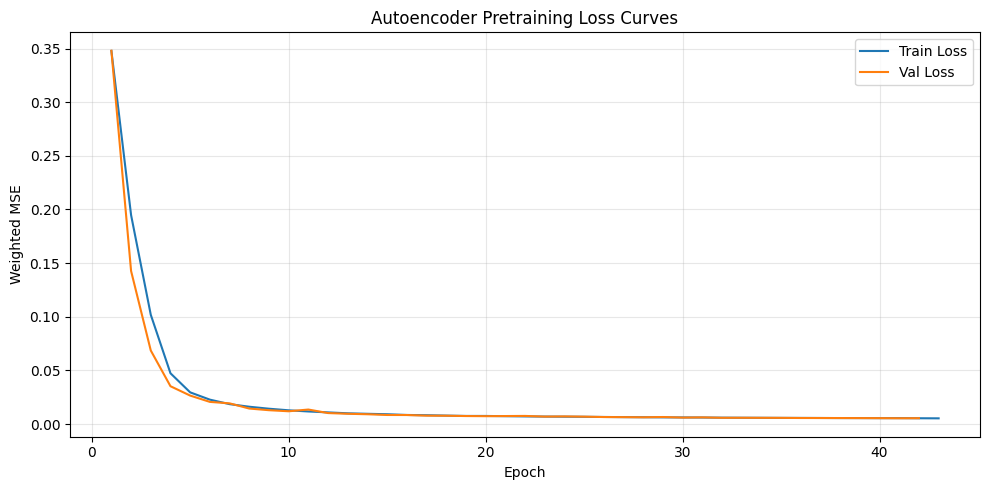

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
ax.plot(range(1, len(val_losses) + 1), val_losses, label="Val Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Weighted MSE")
ax.set_title("Autoencoder Pretraining Loss Curves")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

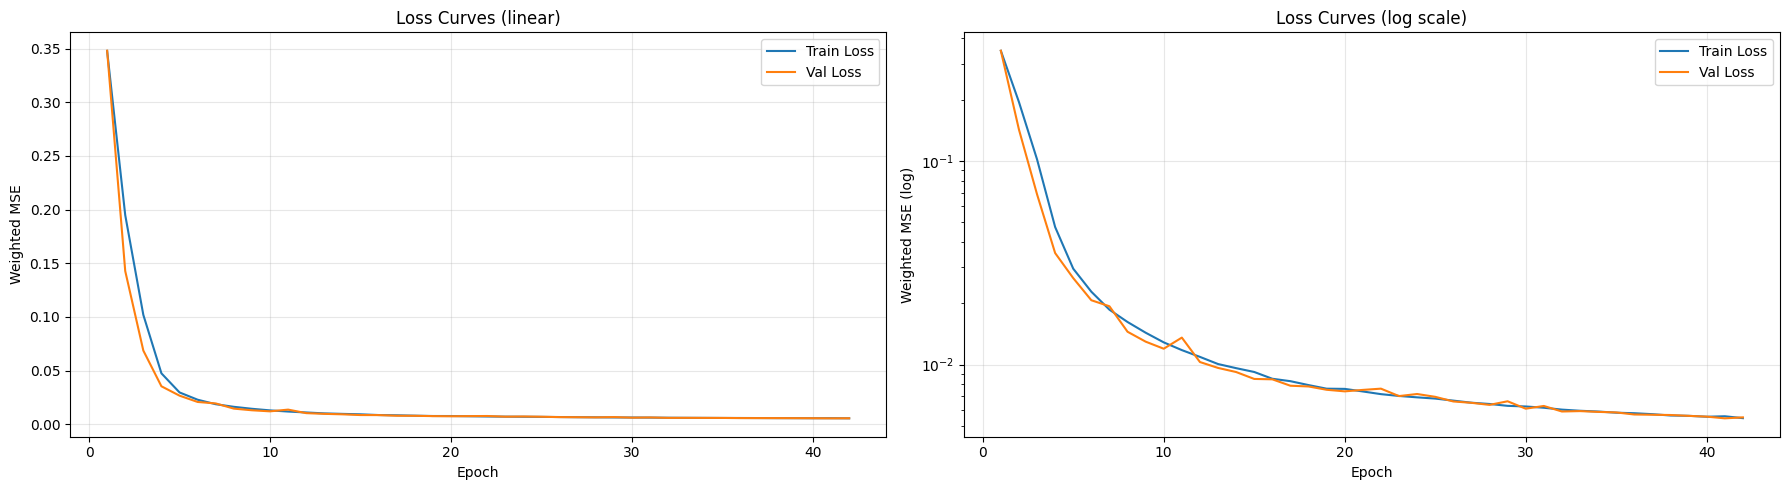

In [43]:
n = min(len(train_losses), len(val_losses))
epochs = range(1, n + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

ax1.plot(epochs, train_losses[:n], label="Train Loss")
ax1.plot(epochs, val_losses[:n], label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Weighted MSE")
ax1.set_title("Loss Curves (linear)")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, train_losses[:n], label="Train Loss")
ax2.plot(epochs, val_losses[:n], label="Val Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Weighted MSE (log)")
ax2.set_yscale("log")
ax2.set_title("Loss Curves (log scale)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## K. Save Pretrained Encoder

Only the `swinViT` encoder weights are saved. The pooling, FC, and decoder layers are discarded.

In [66]:
# Load best checkpoint
best_ckpt = torch.load(
    os.path.join(args.save_dir, "best_ae_model_full.pt"), map_location=device
)
model.load_state_dict(best_ckpt["model_state_dict_full"])
print(f"Loaded best model from epoch {best_ckpt['epoch']} "
      f"(val_loss: {best_ckpt['val_loss']:.6f})")

# Save encoder-only weights (decoder is discarded)
encoder_path = os.path.join(args.save_dir, args.encoder_save_name)
torch.save(model.swinViT.state_dict(), encoder_path)
print(f"Saved pretrained encoder: {encoder_path}")

# Also save the config
import json as _json
cfg_path = os.path.join(args.save_dir, "pretrain_ae_config_full.json")
with open(cfg_path, "w") as f:
    _json.dump({
        k: v for k, v in vars(args).items()
        if isinstance(v, (int, float, str, bool))
    }, f, indent=2)
print(f"Saved config: {cfg_path}")

# Transfer recipe
print("\n--- Transfer into SwinUNETR ---")
print("from monai.networks.nets import SwinUNETR")
print(f"seg_model = SwinUNETR(")
print(f"    img_size={args.img_size}, in_channels={args.in_channels},")
print(f"    out_channels=1, feature_size={args.feature_size}, spatial_dims=2,")
print(f")")
print(f"seg_model.swinViT.load_state_dict(")
print(f"    torch.load('{encoder_path}'), strict=True")
print(f")")

FileNotFoundError: [Errno 2] No such file or directory: './checkpoints/best_ae_model_full.pt'

## L. Final Validation & Visualization

Final validation loss (best model): 0.003894


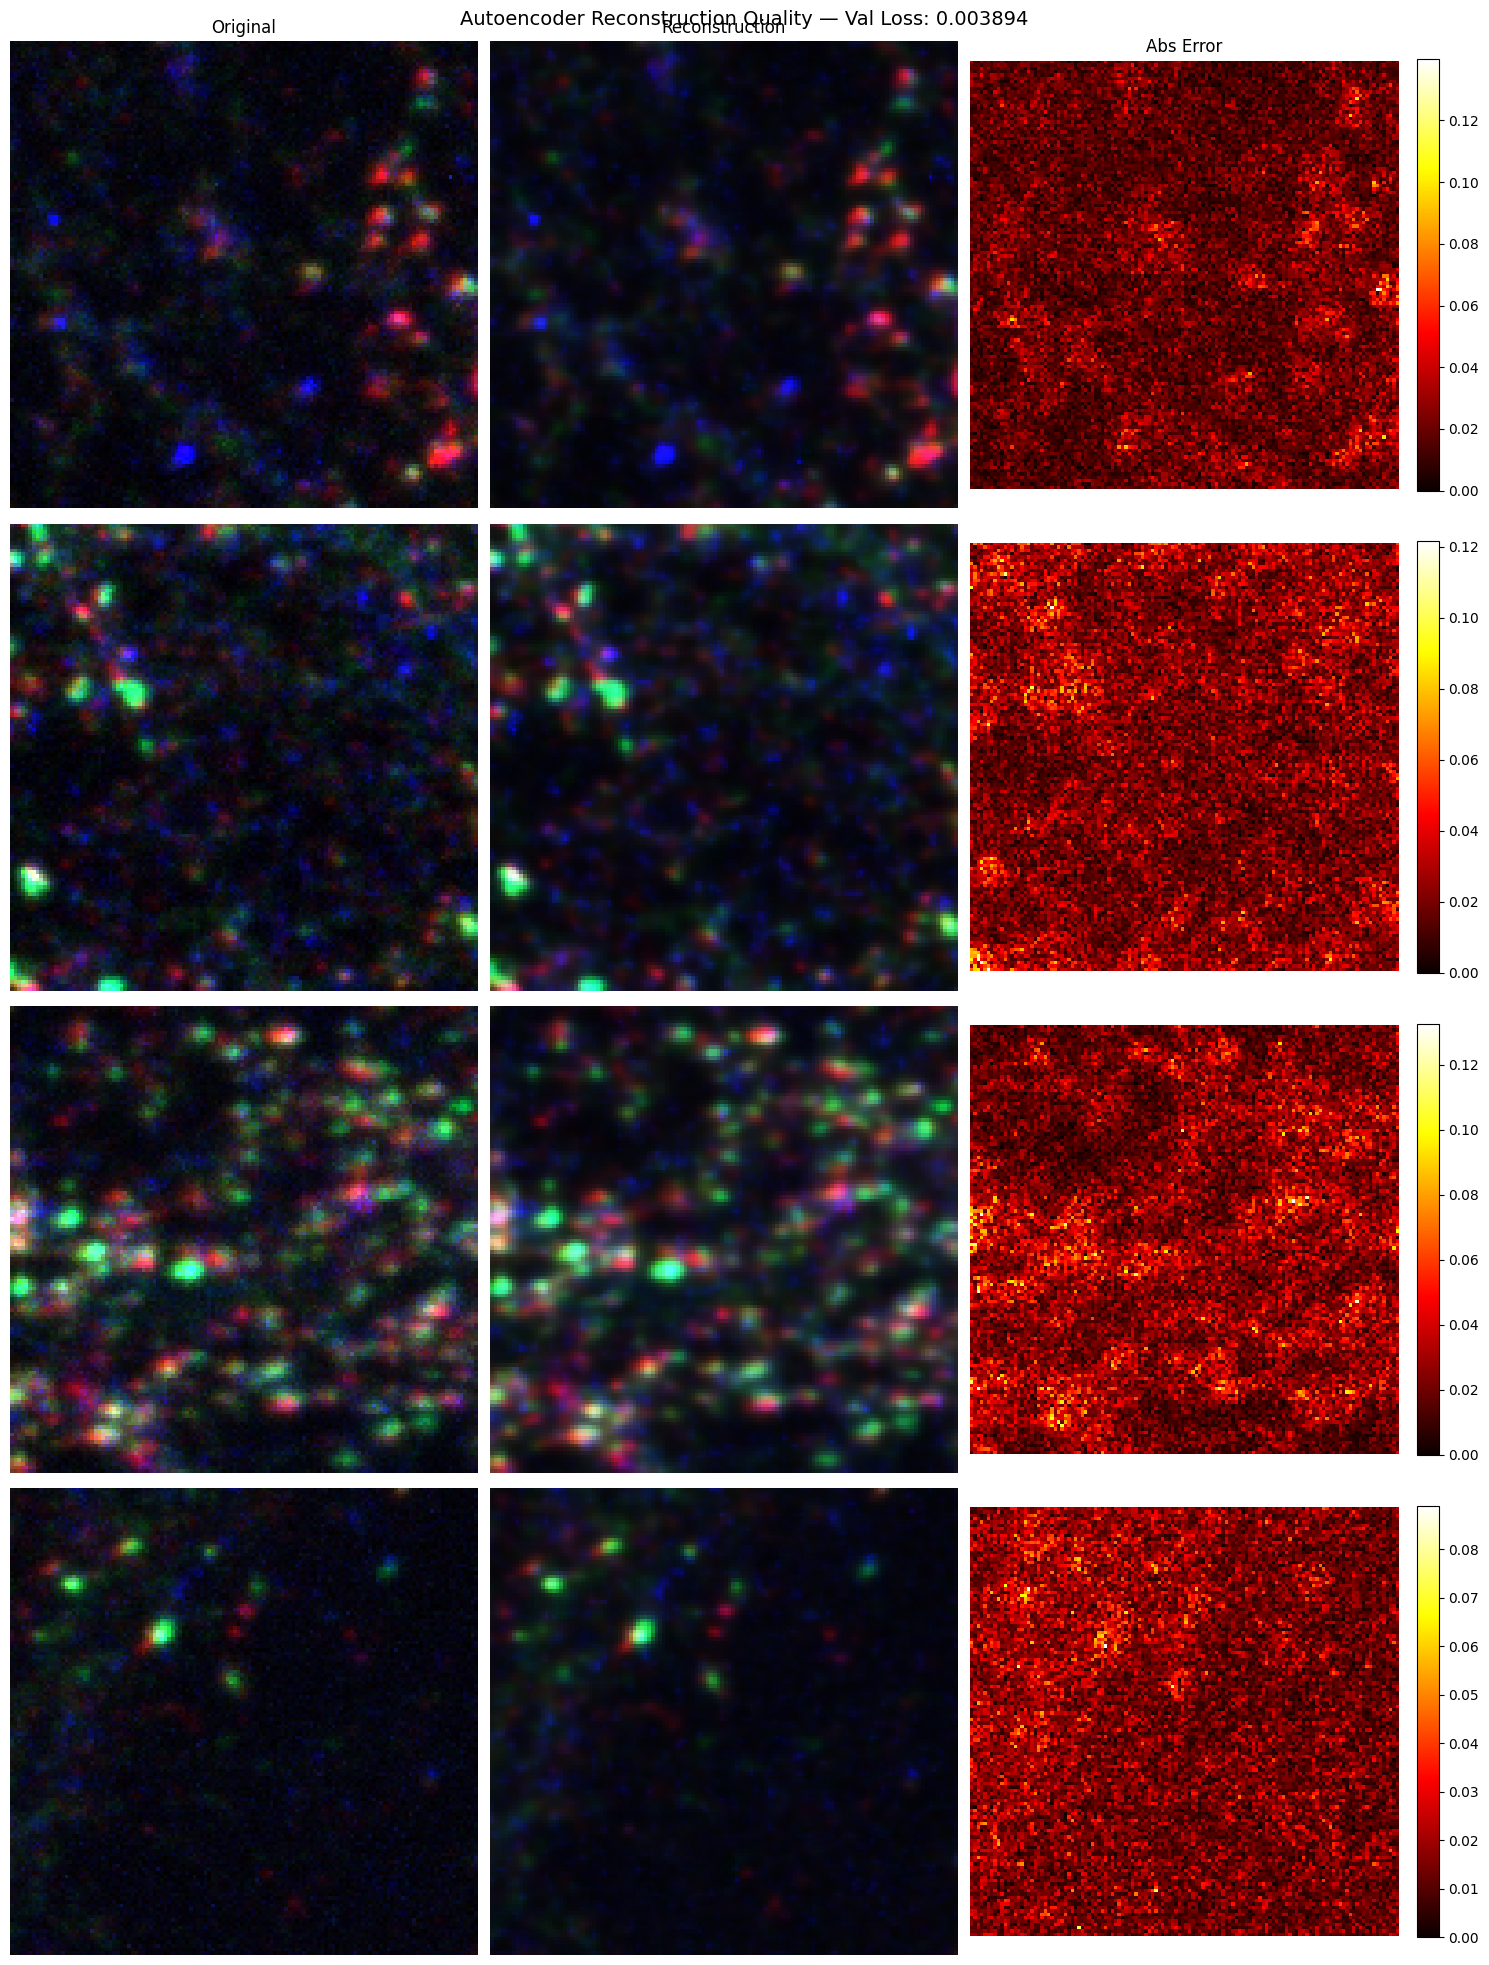

In [65]:
model.eval()
final_val_loss = 0.0
with torch.no_grad():
    for x in val_loader:
        x = x.to(device)
        recon = model(x)
        loss = weighted_mse_loss(recon, x, args.bright_weight)
        final_val_loss += loss.item()

final_val_loss /= len(val_loader)
print(f"Final validation loss (best model): {final_val_loss:.6f}")

# Visualize reconstruction on validation samples
with torch.no_grad():
    sample_batch = next(iter(val_loader))[:4].to(device)
    sample_recon = model(sample_batch)

fig, axes = plt.subplots(4, 3, figsize=(15, 20))
col_titles = ["Original", "Reconstruction", "Abs Error"]

for i in range(4):
    orig = sample_batch[i].cpu()
    rec = sample_recon[i].cpu()

    orig_rgb = orig[:3].permute(1, 2, 0).clamp(0, 1).numpy()
    recon_rgb = rec[:3].permute(1, 2, 0).clamp(0, 1).numpy()
    diff = (orig[:3] - rec[:3]).abs().mean(dim=0).numpy()

    axes[i, 0].imshow(orig_rgb)
    axes[i, 1].imshow(recon_rgb)
    im = axes[i, 2].imshow(diff, cmap="hot", vmin=0, vmax=max(diff.max(), 0.01))
    plt.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04)

    for j, title in enumerate(col_titles):
        if i == 0:
            axes[i, j].set_title(title, fontsize=12)
        axes[i, j].axis("off")

plt.suptitle(f"Autoencoder Reconstruction Quality \u2014 Val Loss: {final_val_loss:.6f}", fontsize=14)
plt.tight_layout()
plt.show()